In [ ]:
#AI4SG Project - Milestone 2

Colab Link
https://colab.research.google.com/drive/1tFDxvcnUKclFW5NxKdproHuYP0xMB3XX?usp=sharing

In [ ]:
!pip install -q google-genai

In [ ]:
from google import genai
from google.colab import userdata
from PIL import Image
import json

API_KEY = userdata.get("GOOGLE_API_KEY")
client = genai.Client(api_key=API_KEY)

MODLE_NAME = "gemini-2.5-flash"

The main point of my project is to make sure that food provided by San Jose's small grocery shops and food pantries is safer. It affects Maria. She workds as a worker at a San Jose food pantry and speaks Spanish. Gathering given food is her job before families arrive. Her schedule isnt always flexible, and she might not understand signs,lebels, or broken packages. The exact point of failure is that the data is there, but it's hard to recognize and use right away. Labels and notes my not be clear, or the package may be broken. SDG 2 (Zero Hunger) and SDG 3 (Good Health and Well-Being) are linked to this because bad food can hurt people and good food might go to waste. There have been no big changes since Milestone 1. The problem, the character,the SDGs, and the labs were all kept the same because they fitted the project well.

input -> Maria enters a small note about the donated food or uploads a picture of the food product.

AI processing -> The AI cleans up jumbled notes by extracting structured data.

Output -> The AI tells Maria about the food item, its condition in the package, worry about its expiration date, risk level, suggested action, and language.

Reality -> Maria or another worker at the food pantry looks over the AI's suggestion before choosing wheather the food should be given out, looked over more carefully, or thrown away. The AI provides help for the human volunteer, but it doesn't make decisions for them.

#Section 3: Project Code

I chose Labs 2 and 3 becuase they work best with my system. Lab 2 is useful when the information is written down but messy, and Lab 3 is useful when Maria needs to make a choice based on what she sees in a picture. Together, they help sort food more quickly and safely.


In [ ]:
labs2_prompt = """
You're helping a volunteer at a food pantry in San Jose who speaks Spanish sort given food.

Take out the payment note and only save it as valid JSON. Please do not add any more information.

Use these fields:
food_item
Package_condition
expiration_concern
risk_level
recommended_action
language
human_review_required
reason

Donation note:
"Leche expire manana y la caja esta un poco danada. Tambien hay una lata de frijoles con una abolladura grande."
"""

response = client.models.generate_content(
    model=MODLE_NAME,
    contents=labs2_prompt
)

print(response.text)

```json
[
  {
    "food_item": "Leche",
    "Package_condition": "caja un poco danada",
    "expiration_concern": "Yes",
    "risk_level": "High",
    "recommended_action": "Descartar por fecha de caducidad inminente y empaque comprometido.",
    "language": "Spanish",
    "human_review_required": false,
    "reason": "La leche es un producto perecedero con fecha de caducidad mañana y el empaque está dañado, lo que representa un alto riesgo para la salud."
  },
  {
    "food_item": "Lata de frijoles",
    "Package_condition": "abolladura grande",
    "expiration_concern": "No",
    "risk_level": "High",
    "recommended_action": "Descartar por abolladura grande que compromete la integridad del envase.",
    "language": "Spanish",
    "human_review_required": false,
    "reason": "Las latas con abolladuras grandes pueden indicar compromiso del sello y riesgo de contaminación, como botulismo."
  }
]
```


In this case, Lab 2 is shown beucase the AI organizes a messy gift note into useful data. Maria doesn't need to read a long note and figure out what's imporrtant. She can quickly see the food item, its condition in the package, weather it's about to go bad, the amount of risk, the action that should be taken, and wheather a human review is needed. This helps my method becuase volunteers at food pantries need quick, clear information before they give food to families.

## Lab 3: Image Recognition

You ca share a picture of a donated food item, a damaged package, a dented a can, an expired food label, or a food container that isn't clear in this area. The AI will look at the picture and indicate if the food is safe to eat.

Saving dented-cans-save-versus-unsafe.jpg to dented-cans-save-versus-unsafe.jpg


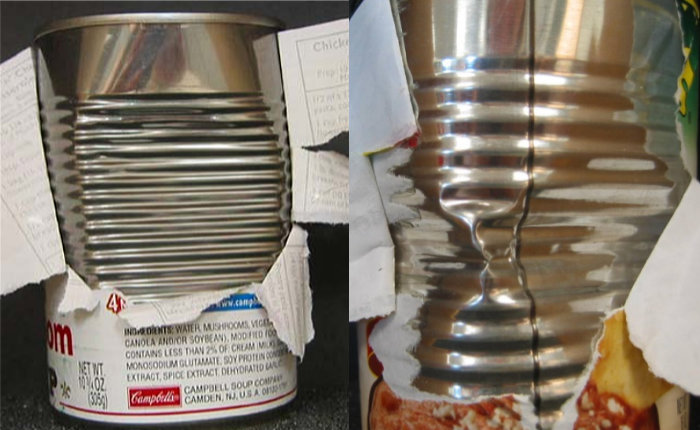

In [ ]:
from google.colab import files

uploaded = files.upload()

image_filename = list(uploaded.keys())[0]
image = Image.open(image_filename)

image

In [ ]:
lab3_prompt = """
You are helping a food pantry volunteer in San Jose inspect a donated food item.

Analyze the image and answer in this exact format:

Food item:
Package condition:
Visible safety concern:
Urgency level:
Recommended action:
Human review required:
Reason:

Be careful. If the image is unclear, damaged, unlabeled, or shows possible food safety human review is required.
"""

response = client.models.generate_content(
    model=MODLE_NAME,
    contents=[lab3_prompt, image]
)

print(response.text)

Food item: Campbell's Soup (likely Cream of Mushroom based on visible label, though "Chick..." is also partially visible on the right, suggesting label is very damaged/unclear)
Package condition: Severely dented can with a deep, sharp crevice on the body. Label is extensively torn and missing in several areas.
Visible safety concern: Deep, sharp denting can compromise the integrity of the can's seal or lining, potentially leading to contamination (e.g., botulism). The heavily damaged label also obscures critical information such as best-by dates and full ingredients.
Urgency level: High
Recommended action: Do not accept for donation. Discard the item immediately.
Human review required: Yes
Reason: The can has a severe, sharp dent that could compromise its integrity and seal, posing a significant risk of foodborne illness. The label is also largely missing, making proper identification and dating impossible.


The AI looks at a picture of a given food item, which shows Lab 3. Maria can quickly snap a picture and ask for help choosing if the food needs to be looked over again. This is helpful if the packaging is broken, the signs aren't clear, or the volunteer doesn't know what to do. The AI helps, but a person still makes the final choice.

# Part 4: Getting Rid of Edge Cases

This part uses a tough case that could cause the AI to fail. The system can't fully judge the safety of home-cooked food becuase problems with germs or temperature might not be obvious.

In [ ]:
edge_case_prompt = """
you are helping a food pantry volunteer in San Jose sort donated food.

Extract the donation note into vaild JSON only. Do not add extra explantion

use the feilds:
food_item
package_conditon
expiration_concern
risk_level
recommended_action
language
human_review_required
reason

Donation note:
"My grandma donated homemade soup in a unlabeled plastic container. It smells okay, but it sat in a car for several hours before arriving at the food pantry."
"""

response = client.models.generate_content(
    model=MODLE_NAME,
    contents=edge_case_prompt
)

print(response.text)

```json
{
  "food_item": "homemade soup",
  "package_conditon": "unlabeled plastic container",
  "expiration_concern": "Temperature abuse (sat in car for several hours)",
  "risk_level": "High",
  "recommended_action": "Discard",
  "language": "English",
  "human_review_required": true,
  "reason": "Homemade, unlabeled, and temperature abused (sat in car for several hours) which poses a high risk of bacterial growth, especially for soup."
}
```


For example, I had an unnamed homemade soup that smelled fine but had been sitting in a car for a few hours.

Input: the code cell's result is shown above.

The verdict is "near miss." Even if the AI says food is unsafe, it is still dangerous because temperature exposure and germs are not always easy to see. Someone who isn't paid should not only trust AI to make this kind of food safety choice.

# Section 5: Responsible AI Reflection

An actual failure couldnt be that the AI suggests giving out dangerous home-cooked food because there is no expiration date or obvious signs of spoilage. Real- Life effects include the possiblity that the people who receive the food will get sick. Despite the fact that the homemade soup might look and smell fine, it could still be dangerous after being in the car for a few hours becuase of this failure. A human volunteer must check any homemade, unlabeled, damaged, old, or temperature-sensitive food before it is distributed. This is my oversight choice. If I could make one change, it would be to require a manual review for food things that aren't obvious. Although this lessens the harm, it require a manual review for food things that aren't obvious. Although this lessens the harm, it requires more volunteer time and doesn't make the process as easy.